In [2]:
import numpy as np 
import pandas as pd  
from sklearn.linear_model import LinearRegression ,Ridge,Lasso 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.svm import SVR 
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRFRegressor
from sklearn.metrics import * 
import warnings 


In [3]:
df=pd.read_csv(r'E:\mlproject\archive/StudentsPerformance.csv')
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [4]:
x=df.drop('math score',axis=1)
x

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [5]:
y=df['math score']
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64

In [6]:
numerical_column=[col for col in x.columns if df[col].dtype!='O']
categorical_column = [col for col in x.columns if df[col].dtype =='O']
print('categorical columns : ',categorical_column)
print('numerical column : ',numerical_column)

categorical columns :  ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
numerical column :  ['reading score', 'writing score']


In [7]:
from sklearn.preprocessing import OneHotEncoder ,StandardScaler
from sklearn.compose import ColumnTransformer 
le=OneHotEncoder() 
scale=StandardScaler() 
preproceser = ColumnTransformer(
    [
        ('Lable encoder',le,categorical_column),
        ('Standard scaler',scale,numerical_column)
    ]
)

preproceser

ColumnTransformer(transformers=[('Lable encoder', OneHotEncoder(),
                                 ['gender', 'race/ethnicity',
                                  'parental level of education', 'lunch',
                                  'test preparation course']),
                                ('Standard scaler', StandardScaler(),
                                 ['reading score', 'writing score'])])

In [8]:
x_scale=preproceser.fit_transform(x)
x_scale

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]])

In [9]:
x_scale.shape

(1000, 19)

In [10]:
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test = train_test_split(x_scale,y,test_size=0.2,random_state=42)
print('train shape',x_train.shape)
print('test shape',x_test.shape)

train shape (800, 19)
test shape (200, 19)


In [12]:
models={
    'linear model':LinearRegression(),
    'Ridge':Ridge(),
    'Lasso':Lasso(),
    'k-nearest Regresser': KNeighborsRegressor(),
    'Decsion tree' : DecisionTreeRegressor(),
    'Random forest regresser': RandomForestRegressor(),
    'Xg boost regresser': XGBRFRegressor()
}

In [17]:
def evalute_model(actual,predict):
    mae=mean_absolute_error(actual,predict)
    mse = mean_squared_error(actual,predict)
    rmse = np.sqrt(mse)
    r2_scor = r2_score(actual,predict)
    return mae,rmse, r2_scor

In [ ]:
models_list=[] 
r2_score_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(x_train,y_train) # train the model..  

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    model_train_mae, model_train_rmse, model_train_r2_score = evalute_model(y_train,y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2_score = evalute_model(y_test,y_test_pred) 

    print(list(models.keys())[i])

    models_list.append(list(models.keys())[i])

    print('Model performance for training data..') 
    print('Root mean squared error for traing data :', model_train_rmse)
    print('mean absolute error for traing data :', model_train_mae)
    print('R2 Square for traing data :', model_train_r2_score) 
    
    print('=' * 50) 

    print('Model performance for testing data..') 
    print('Root mean squared error for testing data :', model_test_rmse)
    print('mean absolute error for testing data :', model_test_mae)
    print('R2 Square for testing data :', model_test_r2_score) 

    r2_score_list.append(model_test_r2_score)

    print('='* 20)
    print('\n') 


linear model
Model performance for training data..
Root mean squared error for traing data : 5.324323433891533
mean absolute error for traing data : 4.267353515625
R2 Square for traing data : 0.8742571028867208
Model performance for testing data..
Root mean squared error for testing data : 5.395445365164637
mean absolute error for testing data : 4.21484375
R2 Square for testing data : 0.8803689401735338


Ridge
Model performance for training data..
Root mean squared error for traing data : 5.323324922741654
mean absolute error for traing data : 4.26498782372598
R2 Square for traing data : 0.8743042615212909
Model performance for testing data..
Root mean squared error for testing data : 5.390387016935637
mean absolute error for testing data : 4.211100688014259
R2 Square for testing data : 0.8805931485028738


Lasso
Model performance for training data..
Root mean squared error for traing data : 6.593815587795566
mean absolute error for traing data : 5.206302661246526
R2 Square for traing

In [21]:
r2_df=pd.DataFrame(zip(models_list,r2_score_list),columns=['Model name', 'R2 score']).sort_values(by=['R2 score'],ascending=False)
r2_df

,Model name,R2 score
1,Ridge,0.880593
0,linear model,0.880369
6,Xg boost regresser,0.862928
5,Random forest regresser,0.853255
2,Lasso,0.825320
3,k-nearest Regresser,0.783813
4,Decsion tree,0.746403


### Ridge Regression 

In [26]:
ridge_model=Ridge()
ridge_model.fit(x_train,y_train)
y_pred = ridge_model.predict(x_test) 
score = r2_score(y_test,y_pred)
print('R2 score :',score.round(4)*100)

R2 score : 88.06


PLOTING

Text(0, 0.5, 'Predicted')

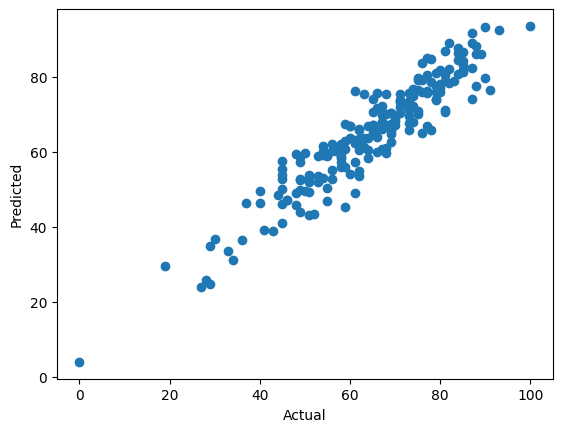

In [27]:
import matplotlib.pyplot as plt      
plt.scatter(y_test,y_pred)  
plt.xlabel('Actual') 
plt.ylabel('Predicted')